# Dirty Cafe Sales Analysis
### Business Scenario
You have been hired as a junior data analyst by a cafe. The cafe has provided transaction data and wants to understand its performance.



In [39]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [40]:
# Load the data
df = pd.read_csv("C:/Users/hp/Documents/Python For Data Analyst and Data Apps/Dirty cafe sales/dirty_cafe_sales.csv")

In [41]:
# Dataset shape
df.shape

(10000, 8)

In [42]:
# Columns
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='str')

In [43]:
# Preview the data
# First rows
df.head(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,08/09/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,16/05/2023
2,TXN_4271903,Cookie,4,1,ERROR,Credit Card,In-store,19/07/2023
3,TXN_7034554,Salad,2,5,10,UNKNOWN,UNKNOWN,27/04/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,11/06/2023


In [44]:
# Previewie the Last  rows
# Last 5 rows
df.tail(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2,2,4,NaN,UNKNOWN,30/08/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,02/06/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,02/03/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,02/12/2023
9999,TXN_6170729,Sandwich,3,4,12,Cash,In-store,07/11/2023


In [45]:
# Random samples
df.sample(10)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
4474,TXN_2563505,Sandwich,1,4,4,Cash,Takeaway,27/10/2023
7430,TXN_7006741,Sandwich,UNKNOWN,4,8,Digital Wallet,NaN,30/12/2023
2311,TXN_3388054,Coffee,5,2,10,Cash,NaN,13/11/2023
1371,TXN_3615483,Sandwich,2,4,8,Digital Wallet,NaN,08/09/2023
1886,TXN_1005331,Coffee,1,2,2,Digital Wallet,Takeaway,04/11/2023
5794,TXN_4548715,Sandwich,2,4,8,NaN,NaN,16/02/2023
37,TXN_1080432,Salad,2,5,10,Credit Card,In-store,29/04/2023
1613,TXN_4639621,Coffee,2,ERROR,4,NaN,In-store,12/10/2023
6842,TXN_6622980,Salad,4,5,20,Digital Wallet,Takeaway,26/09/2023
3094,TXN_9818498,Smoothie,3,4,12,Credit Card,Takeaway,01/09/2023


In [46]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


There's  some missing values and incorrect data types in the dataframe.

In [47]:
#Statistic Summary
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3,6,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [48]:
#Selecting columns
# Series
df['Item']

0         Coffee
1           Cake
2         Cookie
3          Salad
4         Coffee
          ...   
9995      Coffee
9996         NaN
9997      Coffee
9998      Cookie
9999    Sandwich
Name: Item, Length: 10000, dtype: str

In [49]:
# Selecting Multiple columns
# 2 brackets for several columns
df[['Quantity', 'Price Per Unit']]

,Quantity,Price Per Unit
0,2,2
1,4,3
2,4,1
3,2,5
4,2,2
...,...,...
9995,2,2
9996,3,NaN
9997,4,2
9998,3,NaN


In [50]:
# Check datatypes
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

In [51]:
# Data Quality
# Checking for missing values
df.isnull().sum()

# method 2
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [52]:
# Duplicate records
df.duplicated().sum()

np.int64(0)

# Data Cleaning
Order Matters:
1. Hidden invalid values 'UNKNOWN', 'ERROR', 'NA', '?'
2. Incorrect Data Types
3. Remove Missing Values
4. Deal with case 'coffee' = 'COFFEE'

In [53]:
#Remove the invalid values with NaN(missing value)
Invalid_values = ['UNKNOWN', 'ERROR', 'NA', '?']
df.replace(Invalid_values, np.nan, inplace=True)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2,4,Credit Card,Takeaway,08/09/2023
1,TXN_4977031,Cake,4,3,12,Cash,In-store,16/05/2023
2,TXN_4271903,Cookie,4,1,NaN,Credit Card,In-store,19/07/2023
3,TXN_7034554,Salad,2,5,10,NaN,NaN,27/04/2023
4,TXN_3160411,Coffee,2,2,4,Digital Wallet,In-store,11/06/2023
...,...,...,...,...,...,...,...,...
9995,TXN_7672686,Coffee,2,2,4,NaN,NaN,30/08/2023
9996,TXN_9659401,NaN,3,NaN,3,Digital Wallet,NaN,02/06/2023
9997,TXN_5255387,Coffee,4,2,8,Digital Wallet,NaN,02/03/2023
9998,TXN_7695629,Cookie,3,NaN,3,Digital Wallet,NaN,02/12/2023


In [54]:
# Recheck for missing values
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

In [55]:
# Fix the incorrect data types
#Change Quantity, Price per unit & Total Spent to numeric values
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

In [56]:
# Change transaction date to date time
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors ='coerce')

In [57]:
# Drop the missing values
df = df.dropna()

In [58]:
# Clean text
df['Item'] = df['Item'].str.strip().str.title()

In [59]:
df.shape

(1191, 8)

## Validation

In [60]:
#Recheck for missing values
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
dtype: int64

In [61]:
#Check dataset shape
df.shape

(1191, 8)

In [62]:
#Check the items
df['Item'].unique()

<StringArray>
['Coffee', 'Salad', 'Sandwich', 'Juice', 'Smoothie', 'Cookie', 'Tea', 'Cake']
Length: 8, dtype: str

In [63]:
#Recheck the datatypes
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

In [64]:
#Summary of Stateistics
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,1191.000000,1191.00000,1191.000000,1191
mean,2.989924,2.90806,8.733417,2023-06-24 05:48:12.695214
min,1.000000,1.00000,1.000000,2023-01-01 00:00:00
25%,2.000000,1.50000,4.000000,2023-04-03 00:00:00
50%,3.000000,3.00000,7.500000,2023-07-01 00:00:00
75%,4.000000,4.00000,12.000000,2023-09-12 00:00:00
max,5.000000,5.00000,25.000000,2023-12-12 00:00:00
std,1.420107,1.29938,6.008755,NaN


## Business Questions

In [65]:
# How many sales did each product/item have
df['Item'].value_counts()

Item
Cookie      162
Juice       154
Salad       151
Tea         149
Coffee      148
Sandwich    144
Cake        143
Smoothie    140
Name: count, dtype: int64

In [66]:
#What is our best seller?
df['Item'].value_counts().idxmax()

'Cookie'

In [67]:
#What is the average quantity ordered per transaction?
df['Quantity'].mean()

np.float64(2.9899244332493704)

In [68]:
#What is the total quantity sold?
df['Quantity'].sum()

np.float64(3561.0)

In [69]:
#Creating a new column
df['Revenue'] = df['Quantity'] * df['Price Per Unit']

In [70]:
#Preview the data
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Revenue
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-08-09,4.0
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-11-06,4.0
10,TXN_2548360,Salad,5.0,5.0,25.0,Cash,Takeaway,2023-07-11,25.0
12,TXN_7619095,Sandwich,2.0,4.0,8.0,Cash,In-store,2023-03-05,8.0
22,TXN_5132361,Sandwich,3.0,4.0,12.0,Digital Wallet,Takeaway,2023-01-12,12.0


In [71]:
# Total Revenue
df['Revenue'].sum()

np.float64(10401.5)

In [72]:
#Revenue Per Item
df.groupby('Item')['Revenue'].sum()

Item
Cake        1308.0
Coffee       872.0
Cookie       462.0
Juice       1338.0
Salad       2300.0
Sandwich    1780.0
Smoothie    1644.0
Tea          697.5
Name: Revenue, dtype: float64

In [73]:
#sort revenue per Item sold
df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)

Item
Salad       2300.0
Sandwich    1780.0
Smoothie    1644.0
Juice       1338.0
Cake        1308.0
Coffee       872.0
Tea          697.5
Cookie       462.0
Name: Revenue, dtype: float64

In [75]:
#total quantity ordered per location
df.groupby('Location')['Quantity'].sum()

Location
In-store    1754.0
Takeaway    1807.0
Name: Quantity, dtype: float64

## Visualization

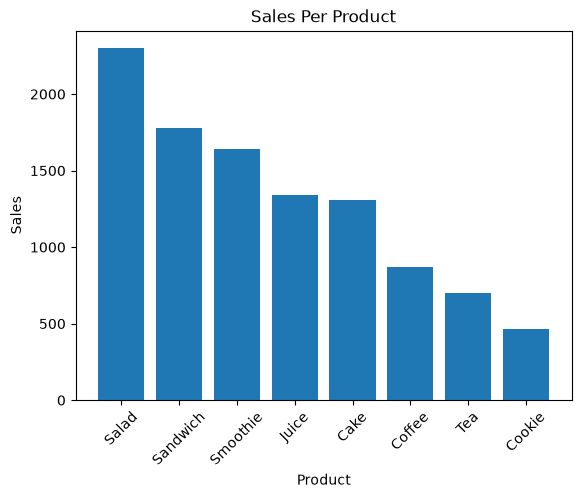

In [83]:
#Sales Per Item
sales_by_item = df.groupby('Item')['Revenue'].sum().sort_values(ascending=False)

plt.bar(sales_by_item.index, sales_by_item.values)
plt.title('Sales Per Product')
plt.xlabel('Product')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

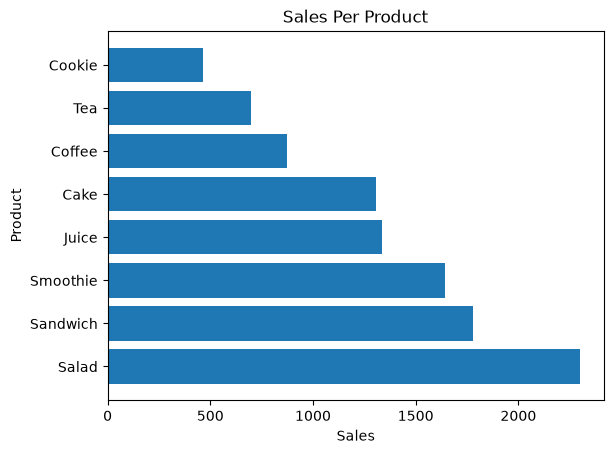

In [84]:
#Horizontal barchart
plt.barh(sales_by_item.index, sales_by_item.values)
plt.title('Sales Per Product')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

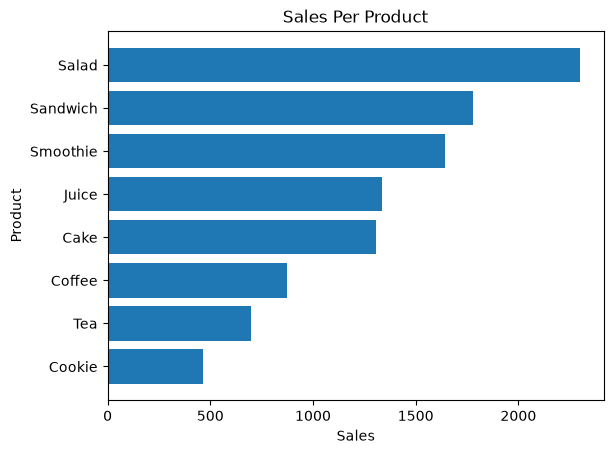

In [85]:
#Horizontal barchart
plt.barh(sales_by_item.index[::-1], sales_by_item.values[::-1])
plt.title('Sales Per Product')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

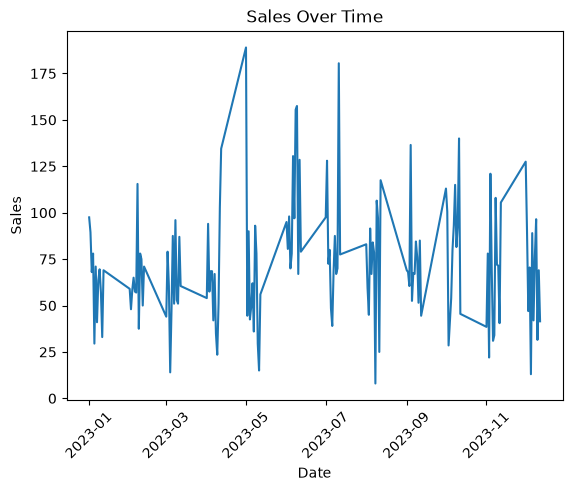

In [87]:
#Sales trend over time
daily_sales = df.groupby('Transaction Date')['Revenue'].sum()
plt.plot(daily_sales.index, daily_sales.values)
plt.title('Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

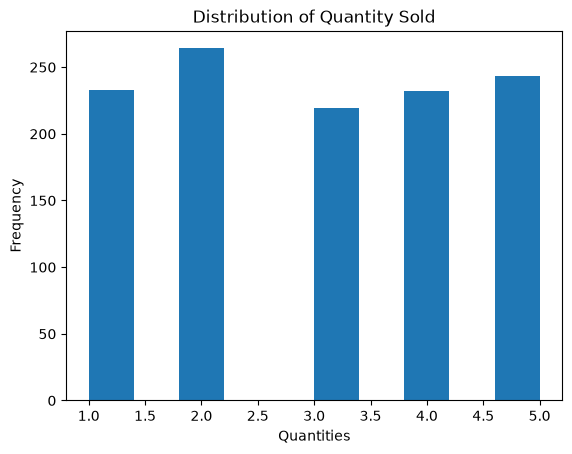

In [88]:
# How the quantities sold are distributed?
plt.hist(df['Quantity'], bins=10)
plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantities')
plt.ylabel('Frequency')
plt.show()

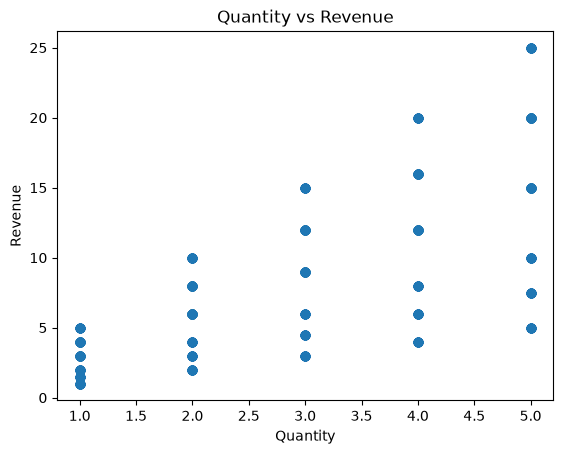

In [90]:
# Is there a relationship between quantity sold and revenue?

plt.scatter(df['Quantity'], df['Revenue'])
plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.show()